In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.cluster import KMeans
from matplotlib.colors import LogNorm

In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["font.size"] = 5

In [4]:
data = pd.read_csv('gaia_stars_processed.csv')
print(f"Dataset contains {len(data)} stars")
print("\nData columns:", data.columns.tolist())

Dataset contains 70118 stars

Data columns: ['ra', 'dec', 'parallax', 'parallax_error', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'bp_rp', 'radial_velocity', 'ruwe', 'teff_gspphot', 'phot_variable_flag', 'distance_pc', 'abs_mag']


1. Basic H-R 

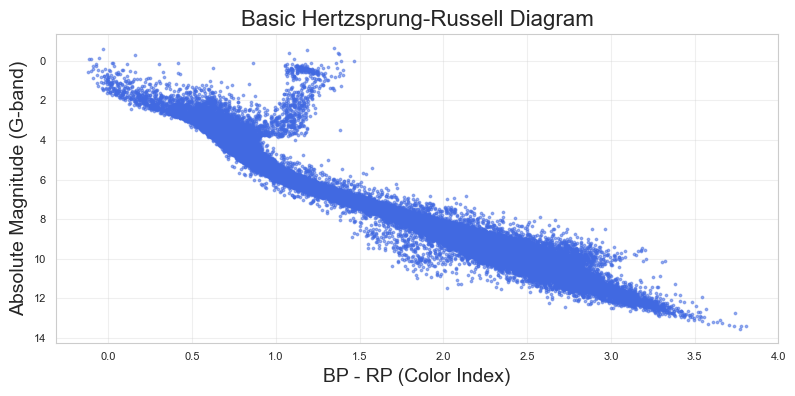

In [12]:
plt.scatter(
    data['bp_rp'], 
    data['abs_mag'], 
    s=3, 
    alpha=0.5,
    c='royalblue'
)
plt.gca().invert_yaxis()
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.title('Basic Hertzsprung-Russell Diagram', fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

2. Temperature based

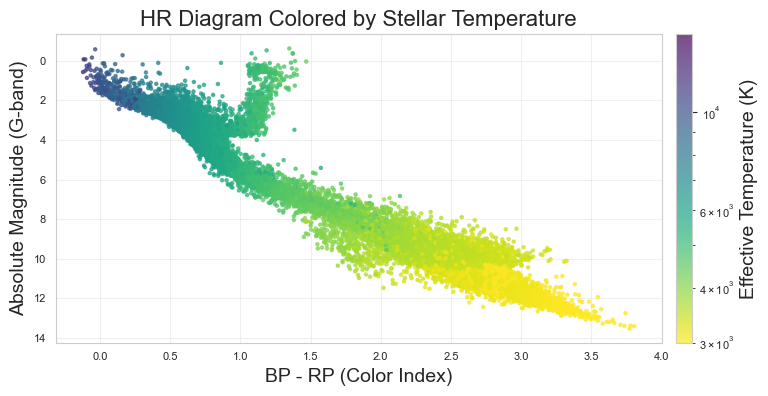

In [11]:
# Create scatter plot colored by temperature
sc = plt.scatter(
    data['bp_rp'], 
    data['abs_mag'], 
    c=data['teff_gspphot'], 
    s=5, 
    alpha=0.7,
    cmap='viridis_r',  # Reverse viridis so hotter = bluer
    norm=LogNorm(vmin=3000, vmax=15000)  # Log scale for better color distribution
)

# Add colorbar
cbar = plt.colorbar(sc, pad=0.02)
cbar.set_label('Effective Temperature (K)', fontsize=14)

# Format plot
plt.gca().invert_yaxis()
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.title('HR Diagram Colored by Stellar Temperature', fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

3. density visualization: Highlight regions of high stellar density

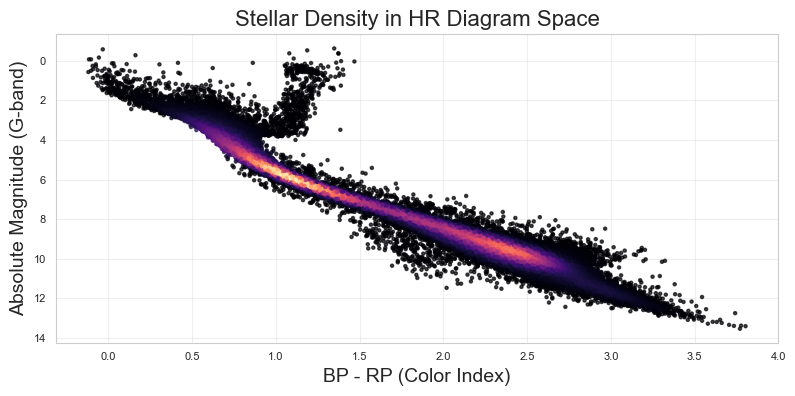

In [13]:
# Calculate point density
xy = np.vstack([data['bp_rp'], data['abs_mag']])
z = gaussian_kde(xy)(xy)

# Create scatter plot with density coloring
plt.scatter(
    data['bp_rp'], 
    data['abs_mag'], 
    c=z, 
    s=5, 
    alpha=0.7,
    cmap='magma'
)

# Format plot
plt.gca().invert_yaxis()
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.title('Stellar Density in HR Diagram Space', fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

5. Stllar phase identification: Classify stars into evolutionary phases

In [14]:
# Define regions for different evolutionary phases
def identify_stellar_phase(bp_rp, abs_mag):
    if abs_mag > 10 and bp_rp < 0.5:
        return 'White Dwarf'
    elif abs_mag < 0 and bp_rp > 1.0:
        return 'Supergiant'
    elif abs_mag < 3 and bp_rp > 1.0:
        return 'Giant'
    elif -1 < abs_mag < 10 and 0 < bp_rp < 2.5:
        return 'Main Sequence'
    else:
        return 'Other'

# Apply classification
data['phase'] = data.apply(
    lambda row: identify_stellar_phase(row['bp_rp'], row['abs_mag']), 
    axis=1
)

# Count stars in each phase
phase_counts = data['phase'].value_counts()
print("\nStellar phase distribution:")
print(phase_counts)


Stellar phase distribution:
phase
Main Sequence    58046
Other            11673
Giant              393
Supergiant           6
Name: count, dtype: int64


5. Phase HR

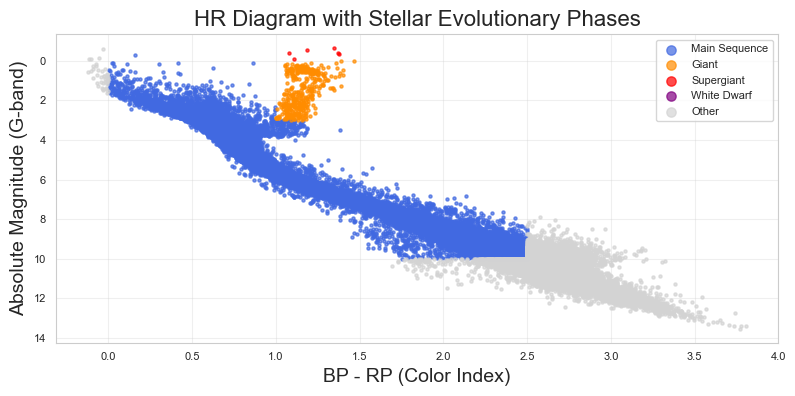

In [16]:
phase_colors = {
    'Main Sequence': 'royalblue',
    'Giant': 'darkorange',
    'Supergiant': 'red',
    'White Dwarf': 'purple',
    'Other': 'lightgray'
}

for phase, color in phase_colors.items():
    phase_data = data[data['phase'] == phase]
    plt.scatter(
        phase_data['bp_rp'], 
        phase_data['abs_mag'], 
        s=5, 
        alpha=0.7,
        color=color,
        label=phase
    )

# Format plot
plt.gca().invert_yaxis()
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.title('HR Diagram with Stellar Evolutionary Phases', fontsize=16)
plt.legend(markerscale=3)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

6. K-Means for phase identification

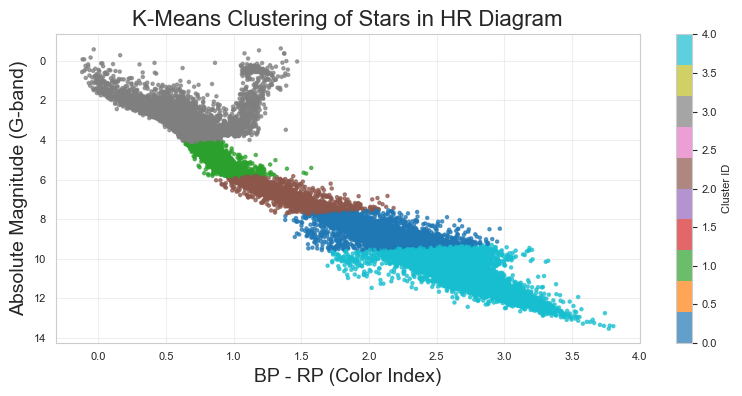

In [33]:
X = data[['bp_rp', 'abs_mag']].copy()

# K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(X)

sc = plt.scatter(
    data['bp_rp'], 
    data['abs_mag'], 
    c=data['cluster'], 
    s=5, 
    alpha=0.7,
    cmap='tab10'
)

plt.gca().invert_yaxis()
plt.xlabel('BP - RP (Color Index)', fontsize=14)
plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
plt.title('K-Means Clustering of Stars in HR Diagram', fontsize=16)
plt.colorbar(sc, label='Cluster ID')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Analyze cluster characteristics
cluster_stats = data.groupby('cluster')[['bp_rp', 'abs_mag', 'teff_gspphot']].mean()
print("\nCluster characteristics:")
display(cluster_stats)


Cluster characteristics:


,bp_rp,abs_mag,teff_gspphot
cluster,,,
0,2.089087,8.709387,3812.675176
1,0.888456,5.033659,5543.917595
2,1.336118,6.660768,4629.520793
3,0.658751,3.168505,6301.619254
4,2.554357,10.201753,3407.659152


7. Variable stars : Highlight pulsating stars (e.g., Cepheids, RR Lyrae)

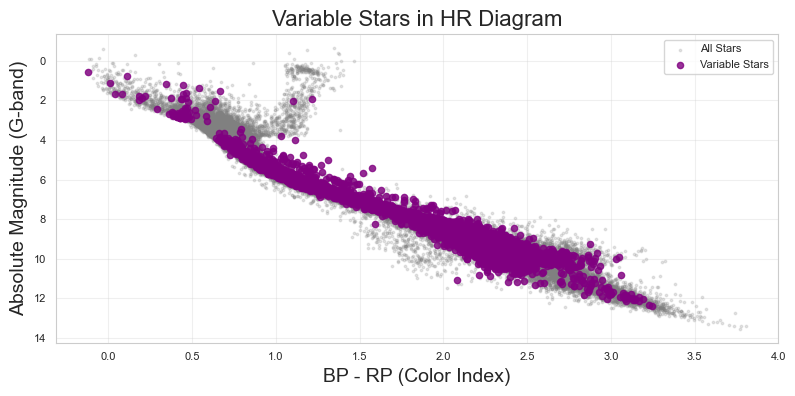

Found 11667 variable stars


In [26]:
if 'phot_variable_flag' in data.columns:
    variables = data[data['phot_variable_flag'] == 'VARIABLE']
    
    # Background stars
    plt.scatter(
        data['bp_rp'], 
        data['abs_mag'], 
        s=3, 
        alpha=0.2,
        c='gray',
        label='All Stars'
    )
    
    # Variable stars
    plt.scatter(
        variables['bp_rp'], 
        variables['abs_mag'], 
        s=20, 
        alpha=0.8,
        c='purple',
        label='Variable Stars'
    )
    
    # Format plot
    plt.gca().invert_yaxis()
    plt.xlabel('BP - RP (Color Index)', fontsize=14)
    plt.ylabel('Absolute Magnitude (G-band)', fontsize=14)
    plt.title('Variable Stars in HR Diagram', fontsize=16)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Found {len(variables)} variable stars")


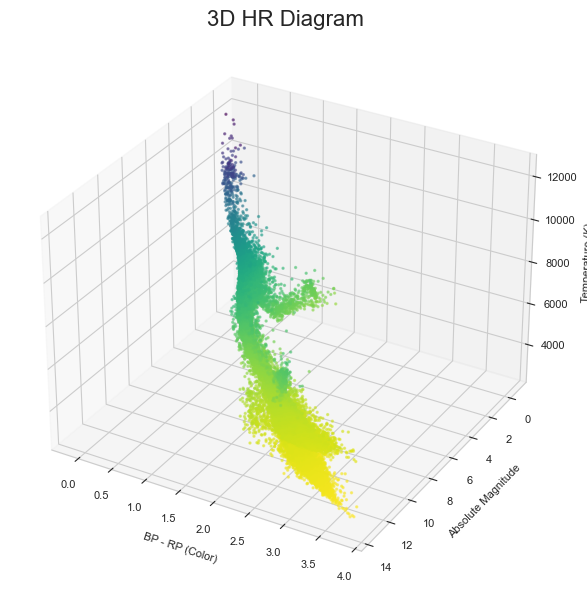

In [32]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    data['bp_rp'], 
    data['abs_mag'], 
    data['teff_gspphot'], 
    c=data['teff_gspphot'],
    s=2,
    alpha=0.5,
    cmap='viridis_r'
)

ax.set_xlabel('BP - RP (Color)')
ax.set_ylabel('Absolute Magnitude')
ax.set_zlabel('Temperature (K)')
ax.set_title('3D HR Diagram', fontsize=16)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

Phase Classification dataset


In [34]:
data.to_csv('gaia_stars_with_phases.csv', index=False)
print("Analysis results saved with stellar phase classifications")

Analysis results saved with stellar phase classifications
